In [1791]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

In [1792]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per (target_instances, d), ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col=[0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by=['seed'] + config_cols)

    # aggregate over seeds
    agg = (df.groupby(config_cols, as_index=False)
             .agg(avg_rmse=('rmse', 'mean'),
                  avg_mae=('val_mae', 'mean'),
                  n_seeds=('seed', 'nunique')))

    # merge back on config_cols only (minimal fix)
    agg = agg.merge(df, on=config_cols, how='left')

    # sort globally by the fields that determine the ranking
    agg = agg.sort_values(by=['target_instances', 'd', 'avg_rmse'], ascending=True)

    # select top-k per (target_instances, d)
    topk_df = agg.groupby(['target_instances', 'd'], group_keys=False).head(k)

    # final compact output
    topk_d = topk_df[['target_instances', 'd', 'method', 'avg_rmse', 'rmse', 'mae']]

    return topk_d, topk_df




In [1793]:
# For gaussian errors, we simply combine previous results with LAD results
data_gaussian = pd.read_csv('results/200_gaussian.csv')
data_gaussian = pd.read_csv('results/gaussian.csv')


# For slash errors
data_slash = pd.read_csv('results/200_slash.csv')
data_slash = pd.read_csv('results/slash.csv')
data_slash = data_slash[data_slash['seed'] != 87]
# data_slash = data_slash[(data_slash['seed'] != 79)
#                           & (data_slash['seed'] != 78)
#                           & (data_slash['seed'] != 77)]
#                          & (data_slash['d'] != 7)
#                          & (data_slash['d'] != 6)]

#data_slash = data_slash[data_slash['seed'] != 52]
# For slash errors
data_t= pd.read_csv('results/200_t.csv')
data_t= pd.read_csv('results/t.csv')
data_t = data_t[data_t['seed'] != 88]
# data_t = data_t[(data_t['seed'] != 79)]
#                 (data_t['d'] != 9)]

# data_t = data_t[data_t['seed'] != 52]

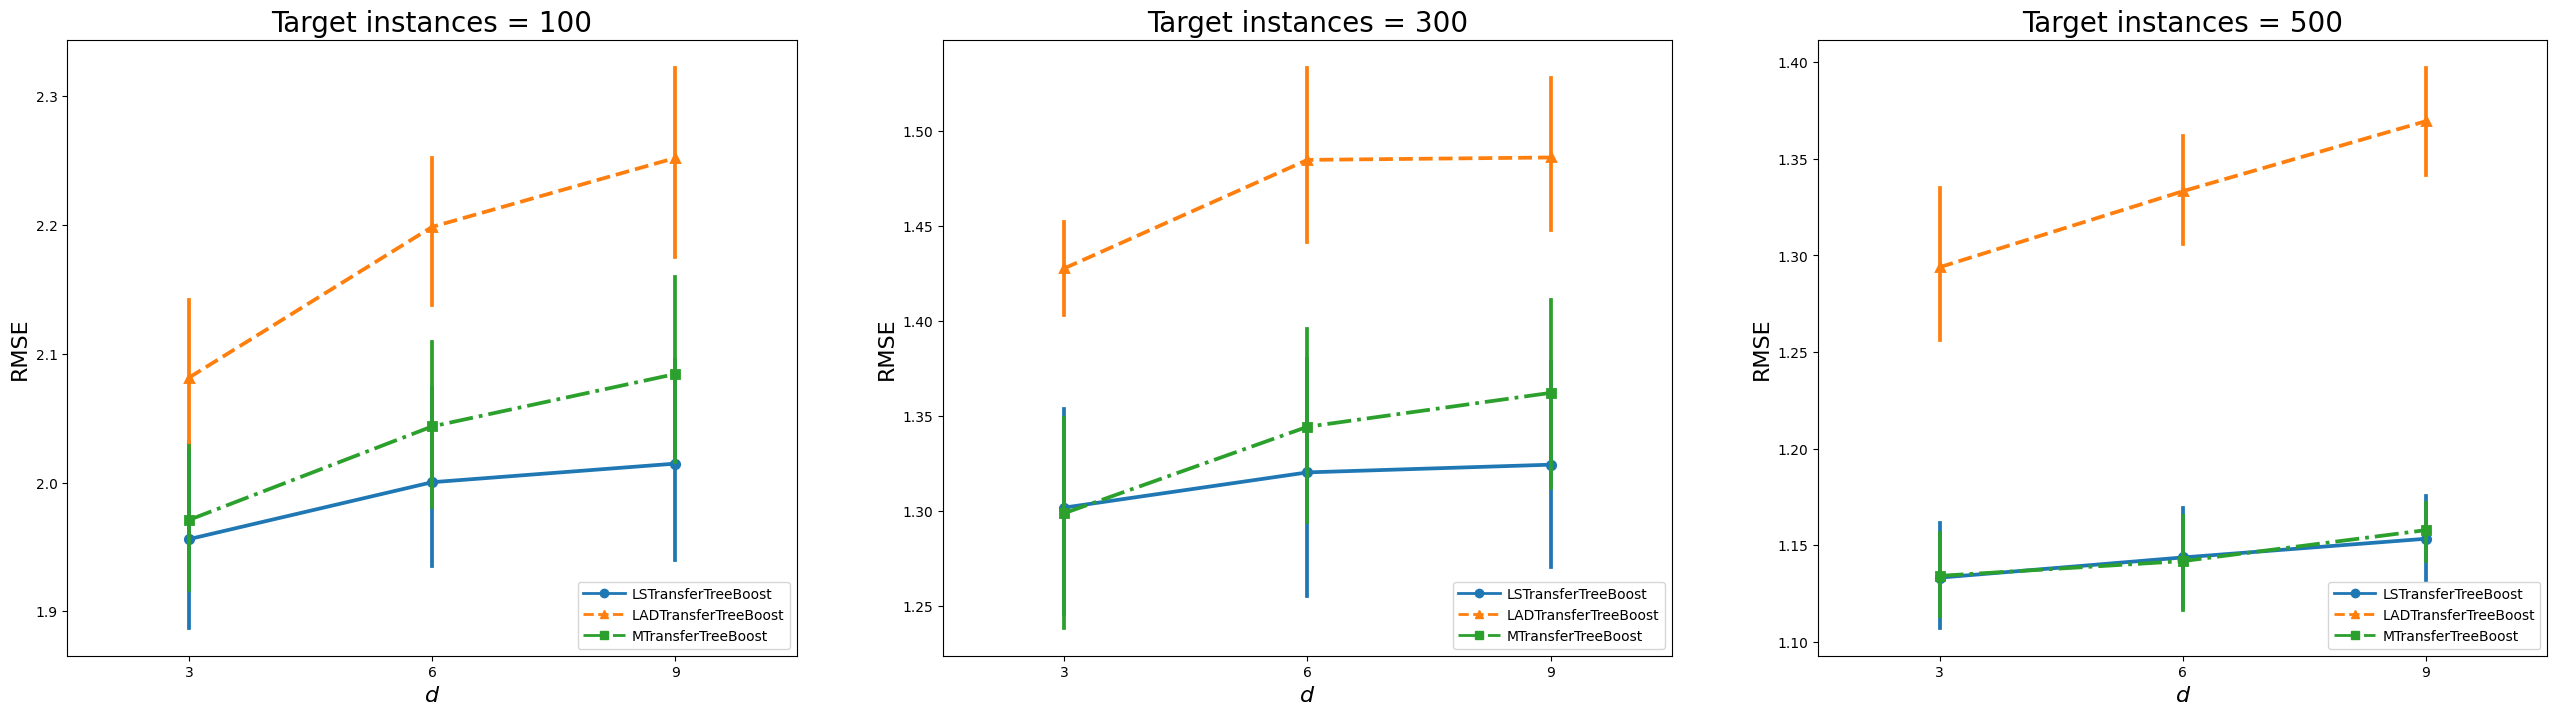

In [1794]:

# Plot average test RMSE:s for best hyperparams
from matplotlib.lines import Line2D

# Here we find the optimal settings
LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_gaussian,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=25
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_gaussian,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=25
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
['target_instances', 'd','v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=25
)

plt.figure(figsize = (32,8))

i = 1
for target_instances in data_gaussian['target_instances'].unique():
    #create new df:s for viz
    df = pd.concat([best_LS[best_LS['target_instances'] == target_instances], best_LAD[best_LAD['target_instances'] == target_instances]])
    df = pd.concat([df, best_Huber[best_Huber['target_instances'] == target_instances]])
    plt.subplot(1,3,i)
    i += 1
    sns.pointplot(data = df, x = 'd', y = 'rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)
    #plt.legend(loc="lower right")
    plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
    plt.gca().set_xlabel('$d$', fontsize=16)
    plt.gca().set_ylabel('RMSE', fontsize=16)
    plt.title(f'Target instances = {target_instances}', fontsize = 20)
plt.show()
    




In [1795]:
# Here we find the default settings
Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost']


best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
['target_instances', 'd','v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=50 # finds the top10 (using 5 seeds)
)

idx = [0] + list(range(5, len(best_Huber_params), 5)) #skip every fifth aas they are simply duplicates on avg_rmse
best_Huber_params_only_params = best_Huber_params.iloc[idx]

df = best_Huber_params_only_params.copy()

counts = (
    df.groupby(['v', 
                'source_tree_size', 'target_tree_size', 
                'm_0', 'k'])
      .size()
      .reset_index(name="total_rank")
)
counts = counts.sort_values(by = 'total_rank', ascending = False)
counts




,v,source_tree_size,target_tree_size,m_0,k,total_rank
26,0.10,2,2,0.9,0.01,6
27,0.10,3,1,0.1,0.00,5
37,0.10,3,2,0.9,0.01,5
11,0.05,3,2,0.9,0.01,4
24,0.10,2,2,0.5,0.00,4
33,0.10,3,1,0.9,0.05,4
30,0.10,3,1,0.5,0.01,4
34,0.10,3,2,0.5,0.00,3
29,0.10,3,1,0.5,0.00,3
20,0.10,2,1,0.5,0.00,3


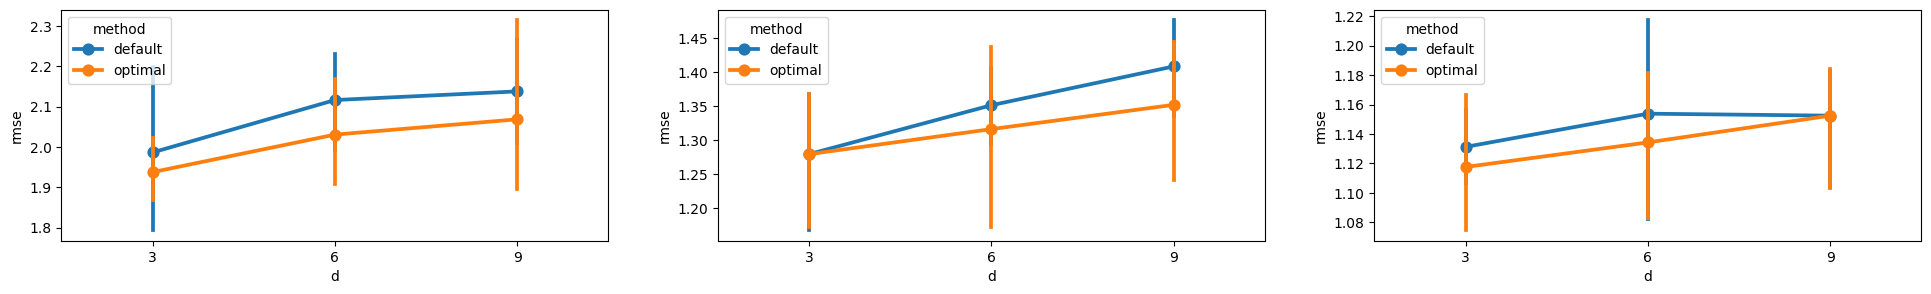

In [1796]:
#compare default settings to optimal settings
default_rows = Huber_data_gaussian[(Huber_data_gaussian['v'] == 0.1) &
                                   (Huber_data_gaussian['source_tree_size'] == 2) &
                                   (Huber_data_gaussian['target_tree_size'] == 2) &
                                   (Huber_data_gaussian['m_0'] == 0.9) &
                                   (Huber_data_gaussian['k'] == 0.01)
                                    
]
default_rows = default_rows[['target_instances', 'd', 'method', 'rmse', 'mae']]
default_rows['method'] = 'default'

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
['target_instances', 'd','v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5 # finds the top10 (using 5 seeds)
)



best_Huber_params = best_Huber_params[['target_instances', 'd', 'method', 'rmse', 'mae']]
best_Huber_params['method'] = 'optimal'
df = pd.concat([default_rows, best_Huber_params])
plt.figure(figsize = (24,3))
i = 1
for target_instances in [100, 300, 500]:
    plt.subplot(1,3,i)
    sns.pointplot(data = df[df['target_instances'] == target_instances], x = 'd', y = 'rmse', hue = 'method')
    i += 1

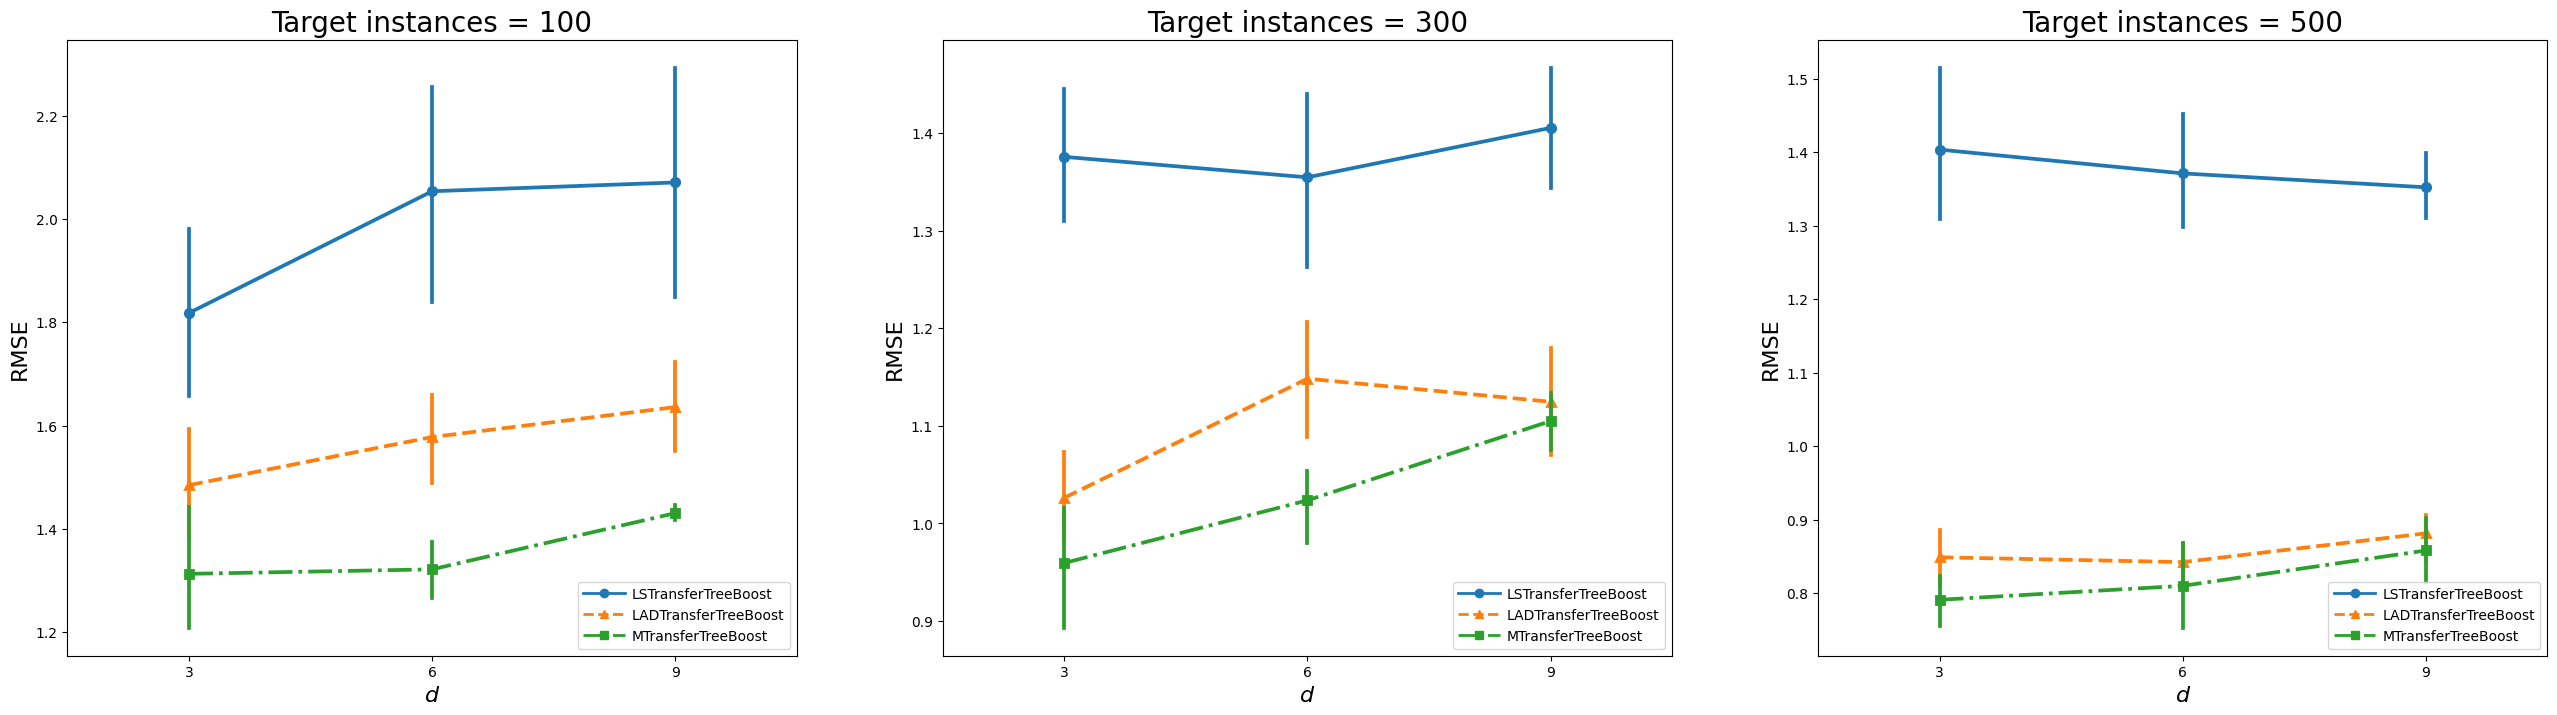

In [1800]:
# Here we find the optimal settings
LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
Huber_data_slash = data_slash[data_slash['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_slash,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=8
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_slash,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=8
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_slash,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=8
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])

plt.figure(figsize = (32,8))

i = 1
for target_instances in data_gaussian['target_instances'].unique():
    #create new df:s for viz
    df = pd.concat([best_LS[best_LS['target_instances'] == target_instances], best_LAD[best_LAD['target_instances'] == target_instances]])
    df = pd.concat([df, best_Huber[best_Huber['target_instances'] == target_instances]])
    plt.subplot(1,3,i)
    i += 1
    sns.pointplot(data = df, x = 'd', y = 'rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)
    #plt.legend(loc="lower right")
    plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
    plt.gca().set_xlabel('$d$', fontsize=16)
    plt.gca().set_ylabel('RMSE', fontsize=16)
    plt.title(f'Target instances = {target_instances}', fontsize = 20)
plt.show()



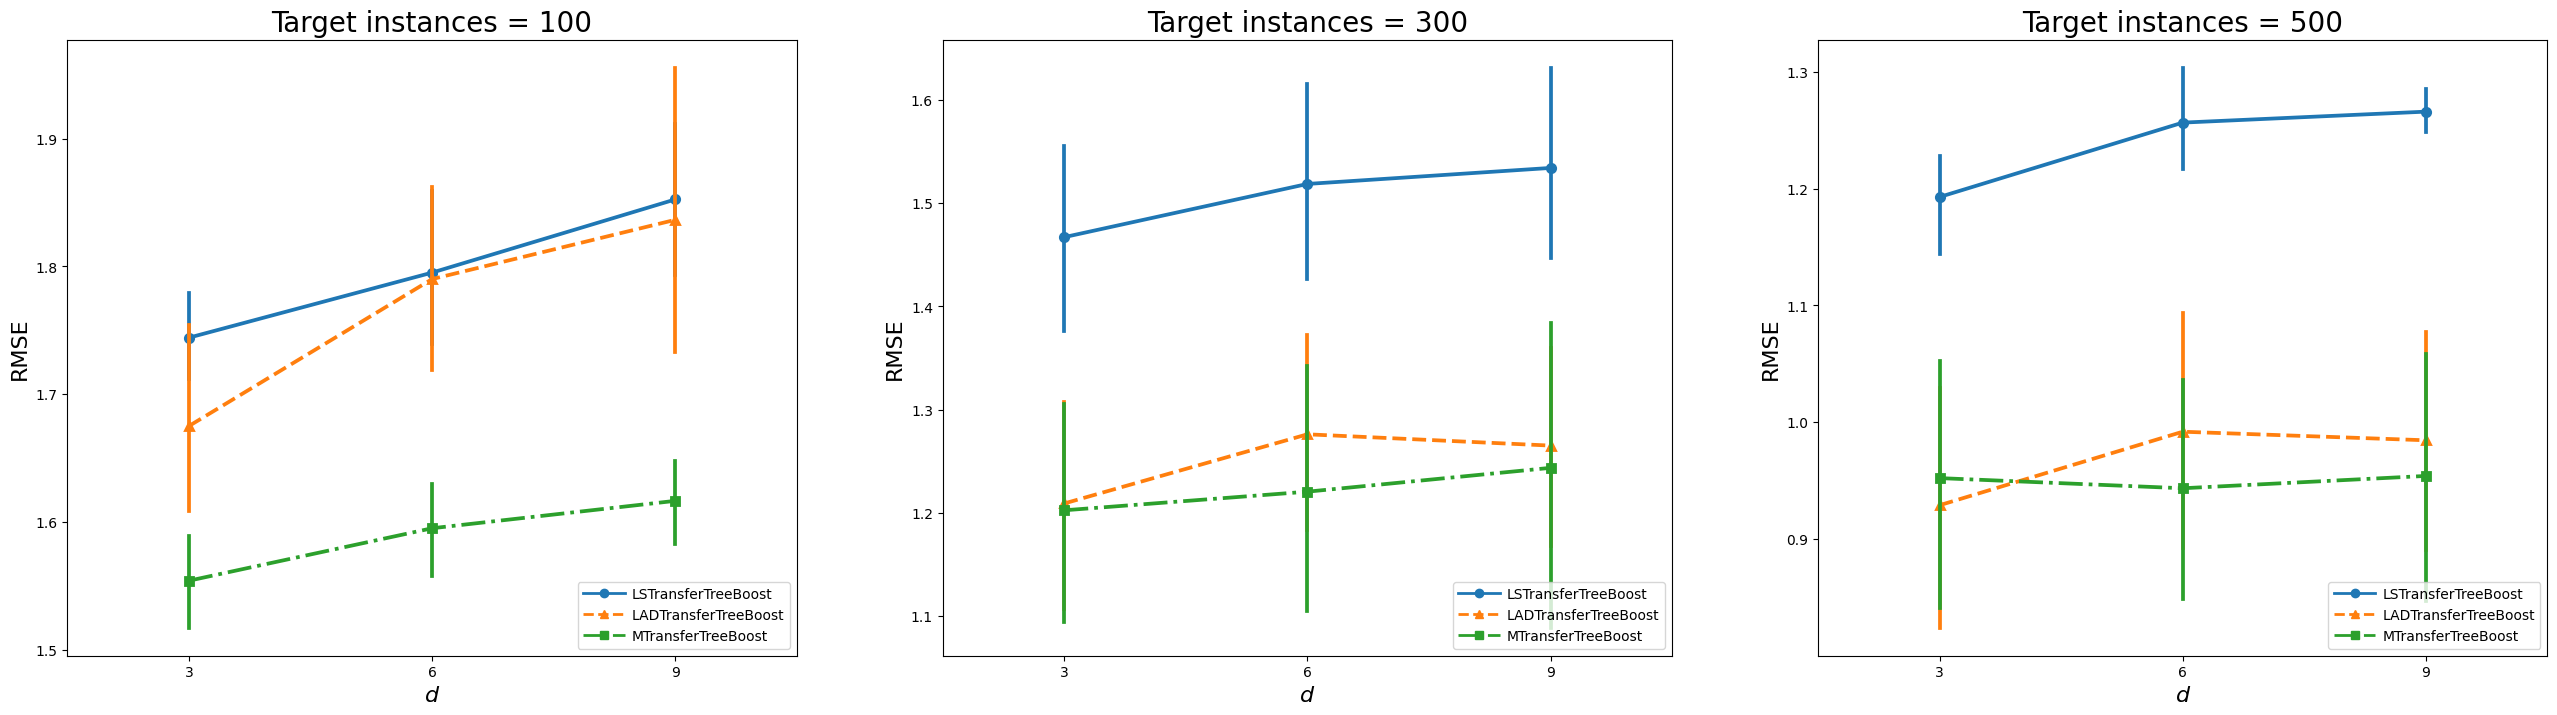

KeyboardInterrupt: 

In [ ]:
# Here we find the optimal settings
LS_data_t = data_t[data_t['method'] == 'LSTransferTreeBoost']
LAD_data_t = data_t[data_t['method'] == 'LADTransferTreeBoost']
Huber_data_t = data_t[data_t['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_t,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=9
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_t,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=9
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_t,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=9
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])

plt.figure(figsize = (32,8))

i = 1
for target_instances in data_gaussian['target_instances'].unique():
    #create new df:s for viz
    df = pd.concat([best_LS[best_LS['target_instances'] == target_instances], best_LAD[best_LAD['target_instances'] == target_instances]])
    df = pd.concat([df, best_Huber[best_Huber['target_instances'] == target_instances]])
    plt.subplot(1,3,i)
    i += 1
    sns.pointplot(data = df, x = 'd', y = 'rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)
    #plt.legend(loc="lower right")
    plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
    plt.gca().set_xlabel('$d$', fontsize=16)
    plt.gca().set_ylabel('RMSE', fontsize=16)
    plt.title(f'Target instances = {target_instances}', fontsize = 20)
plt.show()

In [ ]:
# # Here we compare different quantiles for Huber loss
# Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost'] #read previous result
# Huber_data_gaussian_25 = pd.read_csv('results/200_gaussian_025.csv')
# Huber_data_gaussian_25['method'] = 'M_25'

# Huber_data_gaussian_75 = pd.read_csv('results/200_gaussian_075.csv')
# Huber_data_gaussian_75['method'] = 'M_75'

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_gaussian,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# best_Huber_25, best_Huber_params_25 = topk_per_d_per_method(
#     Huber_data_gaussian_25,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# best_Huber_75, best_Huber_params_75 = topk_per_d_per_method(
#     Huber_data_gaussian_75,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# #create new df for viz
# df = pd.concat([best_Huber, best_Huber_25])
# df = pd.concat([df, best_Huber_75])

# sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

# #Then repeat in two new cells for Slash, t(2)



In [ ]:
# # Here we compare different quantiles for Huber loss
# Huber_data_slash = data_slash[data_slash['method'] == 'MTransferTreeBoost'] #read previous result
# Huber_data_slash_25 = pd.read_csv('results/200_slash_025.csv')
# Huber_data_slash_25['method'] = 'M_25'

# Huber_data_slash_75 = pd.read_csv('results/200_slash_075.csv')
# Huber_data_slash_75['method'] = 'M_75'

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_slash,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# best_Huber_25, best_Huber_params_25 = topk_per_d_per_method(
#     Huber_data_slash_25,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# best_Huber_75, best_Huber_params_75 = topk_per_d_per_method(
#     Huber_data_slash_75,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# #create new df for viz
# df = pd.concat([best_Huber, best_Huber_25])
# df = pd.concat([df, best_Huber_75])

# sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

In [ ]:
# # Here we compare different quantiles for Huber loss
# Huber_data_t = data_t[data_t['method'] == 'MTransferTreeBoost'] #read previous result
# Huber_data_t_25 = pd.read_csv('results/200_t_025.csv')
# Huber_data_t_25['method'] = 'M_25'

# Huber_data_t_75 = pd.read_csv('results/200_t_075.csv')
# Huber_data_t_75['method'] = 'M_75'

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_t,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
# )

# best_Huber_25, best_Huber_params_25 = topk_per_d_per_method(
#     Huber_data_t_25,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
# )

# best_Huber_75, best_Huber_params_75 = topk_per_d_per_method(
#     Huber_data_t_75,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
# )

# #create new df for viz
# df = pd.concat([best_Huber, best_Huber_25])
# df = pd.concat([df, best_Huber_75])

# sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

# Here we make final vizes!

In [ ]:
# # For gaussian errors, we simply combine previous results with LAD results
# data_gaussian = pd.read_csv('results/200_gaussian.csv')

# # For slash errors
# data_slash = pd.read_csv('results/200_slash.csv')

# #for t(2) errors
# data_t= pd.read_csv('results/200_t.csv')



In [ ]:
# # Here we find the optimal settings
# LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
# LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
# Huber_data_gaussian = pd.read_csv('results/200_gaussian_075.csv')

# best_LS, best_LS_params = topk_per_d_per_method(
#     LS_data_gaussian,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_LAD, best_LAD_params = topk_per_d_per_method(
#     LAD_data_gaussian,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_gaussian,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# #create new df for viz
# df = pd.concat([best_LS, best_LAD])
# df = pd.concat([df, best_Huber])
# sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

In [ ]:
# # Here we find the optimal settings
# LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
# LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
# Huber_data_slash = pd.read_csv('results/200_slash_075.csv')

# best_LS, best_LS_params = topk_per_d_per_method(
#     LS_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_LAD, best_LAD_params = topk_per_d_per_method(
#     LAD_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# # create new df for viz
# df = pd.concat([best_LS, best_LAD])
# df = pd.concat([df, best_Huber])
# sns.boxplot(data=df, x='d', y='rmse', hue='method')


In [ ]:

# plt.figure(figsize = (14,16))
# import matplotlib as mpl
# # Here we find the optimal settings
# LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
# LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
# Huber_data_gaussian = pd.read_csv('results/200_gaussian_075.csv')
# LS_data_gaussian['method'] = 'LS'
# LAD_data_gaussian['method'] = 'LAD'
# Huber_data_gaussian['method'] = 'M'

# best_LS, best_LS_params = topk_per_d_per_method(
#     LS_data_gaussian,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_LAD, best_LAD_params = topk_per_d_per_method(
#     LAD_data_gaussian,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_gaussian,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# # create new df for viz
# df = pd.concat([best_LS, best_LAD])
# df = pd.concat([df, best_Huber])
# plt.subplot(3,2,1)
# ax = sns.boxplot(x='d', y='rmse', hue='method', data=df, showfliers=False)
# plt.title('Gaussian', fontsize = 14)
# plt.ylabel('RMSE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')

# plt.subplot(3,2,2)
# ax = sns.boxplot(x='d', y='mae', hue='method', data=df, showfliers=False)
# plt.title('Gaussian', fontsize = 14)
# plt.ylabel('MAE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')


# # Here we find the optimal settings
# LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
# LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
# Huber_data_slash = pd.read_csv('results/200_slash_075.csv')
# LS_data_slash['method'] = 'LS'
# LAD_data_slash['method'] = 'LAD'
# Huber_data_slash['method'] = 'M'

# best_LS, best_LS_params = topk_per_d_per_method(
#     LS_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_LAD, best_LAD_params = topk_per_d_per_method(
#     LAD_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# # create new df for viz
# df = pd.concat([best_LS, best_LAD])
# df = pd.concat([df, best_Huber])
# plt.subplot(3,2,3)
# ax = sns.boxplot(x='d', y='rmse', hue='method', data=df, showfliers=False)
# plt.title('Slash', fontsize = 14)
# plt.ylabel('RMSE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')

# plt.subplot(3,2,4)
# ax = sns.boxplot(x='d', y='mae', hue='method', data=df, showfliers=False)
# plt.title('Slash', fontsize = 14)
# plt.ylabel('MAE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')


# # Here we find the optimal settings
# LS_data_t = data_t[data_t['method'] == 'LSTransferTreeBoost']
# LAD_data_t = data_t[data_t['method'] == 'LADTransferTreeBoost']
# Huber_data_t = pd.read_csv('results/200_t_075.csv')
# LS_data_t['method'] = 'LS'
# LAD_data_t['method'] = 'LAD'
# Huber_data_t['method'] = 'M'

# best_LS, best_LS_params = topk_per_d_per_method(
#     LS_data_t,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_LAD, best_LAD_params = topk_per_d_per_method(
#     LAD_data_t,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_t,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# # create new df for viz
# df = pd.concat([best_LS, best_LAD])
# df = pd.concat([df, best_Huber])
# plt.subplot(3,2,5)
# ax = sns.boxplot(x='d', y='rmse', hue='method', data=df, showfliers=False)
# plt.title('t(2)', fontsize = 14)
# plt.ylabel('RMSE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')

# plt.subplot(3,2,6)
# ax = sns.boxplot(x='d', y='mae', hue='method', data=df, showfliers=False)
# plt.title('t(2)', fontsize = 14)
# plt.ylabel('MAE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')

# plt.savefig('vizes/esann_viz.png', bbox_inches = 'tight', pad_inches = 0.05, dpi = 300)


# Final viz comes here!!!!
data = pd.read_csv('results/200_gaussian_6_optim.csv')
data_slash = pd.read_csv('results/200_slash_6_optim.csv')
# We remove one very weird result. As this did not happen in any other experiment, 
# we believe this is a numerical issue with the code. We remove the seed for both methods.
data = data[data['seed'] != 18] 
data_slash = data_slash[data_slash['seed'] != 18]
data['method'] = data['method'].replace("LSTransferTreeBoost", "LS")
data['method'] = data['method'].replace("LADTransferTreeBoost", "LAD")

data_slash['method'] = data_slash['method'].replace("LSTransferTreeBoost", "LS")
data_slash['method'] = data_slash['method'].replace("LADTransferTreeBoost", "LAD")

plt.figure(figsize = (14,10))

plt.subplot(2,2,1)
sns.boxplot(data = data, x = 'method', y = 'rmse')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)

plt.subplot(2,2,2)
sns.boxplot(data = data, x = 'method', y = 'mae')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)

plt.subplot(2,2,3)
sns.boxplot(data = data_slash, x = 'method', y = 'rmse')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)

plt.subplot(2,2,4)
sns.boxplot(data = data_slash, x = 'method', y = 'mae')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)

plt.savefig('vizes/ls-lad.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)







In [ ]:
best_Huber_params_only_params

,target_instances,d,v,source_tree_size,target_tree_size,m_0,k,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,method,epochs,val_rmse,val_mae,rmse,mae
445,100,3,0.10,3,1,0.5,0.01,1.553285,1.221993,3,419,85,MTransferTreeBoost,400,1.485104,1.186340,1.544794,1.239458
214,100,3,0.05,3,1,0.9,0.05,1.554143,1.217667,3,188,85,MTransferTreeBoost,400,1.533541,1.222242,1.605534,1.280847
454,100,3,0.10,3,1,0.9,0.01,1.554842,1.199898,3,422,85,MTransferTreeBoost,400,1.511682,1.185381,1.605457,1.274849
943,100,6,0.10,3,1,0.9,0.05,1.571441,1.220472,3,1889,85,MTransferTreeBoost,400,1.520482,1.193062,1.617565,1.271121
934,100,6,0.10,3,1,0.5,0.05,1.604609,1.247155,3,1886,85,MTransferTreeBoost,400,1.554646,1.228338,1.641811,1.300535
925,100,6,0.10,3,1,0.1,0.05,1.609400,1.255142,3,1883,85,MTransferTreeBoost,400,1.523555,1.193331,1.616263,1.267708
1408,100,9,0.10,3,1,0.1,0.01,1.604633,1.251376,3,3332,85,MTransferTreeBoost,400,1.520960,1.200271,1.613706,1.267437
1168,100,9,0.05,3,1,0.1,0.05,1.614678,1.264466,3,3098,85,MTransferTreeBoost,400,1.548383,1.218568,1.643668,1.294806
1405,100,9,0.10,3,1,0.1,0.00,1.630430,1.270521,3,3323,85,MTransferTreeBoost,400,1.571097,1.255234,1.670084,1.322703
1939,300,3,0.10,3,2,0.9,0.01,1.191304,0.926201,3,935,85,MTransferTreeBoost,400,1.333596,1.055878,1.351174,1.071459
